# Token Explorer

How does GPT-4's BPE tokenizer (`cl100k_base`) chop up real text? We grab a book from Project Gutenberg, split it into words, and study how each word breaks down into subword tokens.

**What's here:**
1. Load the text, split it into words, and count word frequencies
2. Tokenize every unique word and record tokens-per-word
3. Visualize tokens-per-word vs. **word length** and vs. **corpus frequency** (scatter + correlations)
4. Pull out specific words — most-fragmented, fixed length, etc.
5. Tokenizer **efficiency**: characters per token, and how it changes with word length
6. Flip the view — pick a token ID and look at **where it appears in the running text**

## Setup

Load the GPT-4 encoder (`cl100k_base`) via OpenAI's `tiktoken`. This is the production BPE: the actual merge rules and ~100k-token vocabulary.

In [26]:
import re
from collections import Counter

import numpy as np
import requests
import matplotlib.pyplot as plt
import tiktoken
from scipy.stats import spearmanr

enc = tiktoken.encoding_for_model("gpt-4")

## Load the text

Pull down *The Time Machine* by H.G. Wells. We split on whitespace **and** a small set of punctuation, then strip empties — the goal is one "word" per real word, without punctuation glued to the ends.

In [27]:
url = "https://www.gutenberg.org/files/35/35-0.txt"  # H.G. Wells, "The Time Machine"
text = requests.get(url).text

words = re.split(r'([,.:;—?_!"“()\']|--|\s)', text)
words = [w.strip() for w in words if w.strip()]

print(f"{len(text):,} chars, {len(words):,} words (split on whitespace + punctuation)")

182,973 chars, 37,786 words (split on whitespace + punctuation)


### Word frequencies

Count how often each word appears in the text. `Counter(words)` is the idiomatic way — it's a `dict` subclass that tallies items in a single pass, and `.most_common(n)` gives the top-n by count for free.

In [28]:
word_counts = Counter(words)

print(f"{len(word_counts):,} unique words")
print("\nTop 10 by frequency:")
for w, n in word_counts.most_common(10):
    print(f"  {n:>5} × {w!r}")

5,007 unique words

Top 10 by frequency:
   2250 × ','
   2066 × 'the'
   1804 × '.'
   1251 × 'I'
   1157 × 'of'
   1150 × 'and'
    795 × 'a'
    672 × 'to'
    552 × 'was'
    508 × 'in'


## Tokenize each unique word

Deduplicate the word list (reusing `word_counts.keys()`), then encode every word in one batch call. We keep four parallel structures, all aligned by index:

- `unique_words` — sorted list of strings
- `token_ids` — list of token-ID lists (per word)
- `token_counts` — array of token counts per word
- `word_lengths` — array of character lengths per word

In [29]:
unique_words = sorted(word_counts)
token_ids = enc.encode_batch(unique_words)
token_counts = np.array([len(ids) for ids in token_ids])
word_lengths = np.array([len(w) for w in unique_words])

print(f"avg tokens/word: {token_counts.mean():.2f}")
print(f"1-token words:   {(token_counts == 1).mean():.1%}")

avg tokens/word: 1.86
1-token words:   34.5%


## How fragmented is the tokenization?

Most short, common words become a single token. Longer or rarer words split into multiple subword pieces. The cells below quantify that distribution, then look at how token count tracks two different predictors: **word length** (a property of the string) and **corpus frequency** (a property of how often it shows up in this text).

In [30]:
vals, counts = np.unique(token_counts, return_counts=True)
for n_tok, n_words in zip(vals, counts):
    print(f"{n_tok} token{'s' if n_tok != 1 else ' '}: {n_words:>6,} words ({n_words / len(unique_words):.1%})")

1 token :  1,727 words (34.5%)
2 tokens:  2,388 words (47.7%)
3 tokens:    787 words (15.7%)
4 tokens:     91 words (1.8%)
5 tokens:     11 words (0.2%)
6 tokens:      1 words (0.0%)
7 tokens:      2 words (0.0%)


### Word length vs. token count

Scatter plot with Gaussian jitter (σ = 0.15) on both axes — both variables are integers, so without jitter every point would stack on a grid. The cell after the plot computes both Pearson (linear) and Spearman (rank) correlations: Pearson assumes a straight-line relationship, Spearman only asks whether one variable rises as the other does.

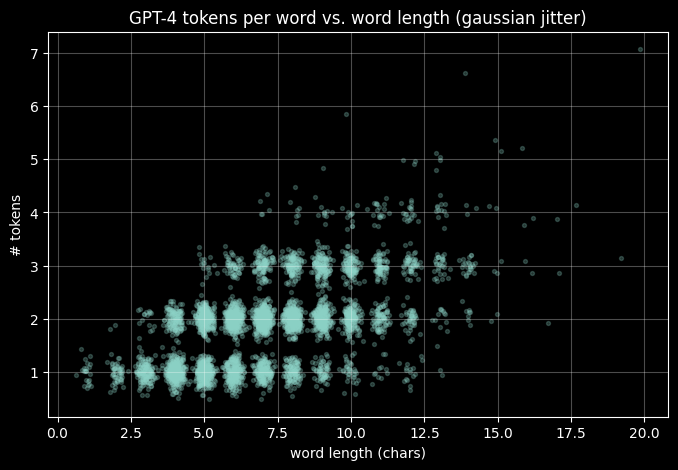

In [31]:
rng = np.random.default_rng(0)
jx = rng.normal(0, 0.15, size=word_lengths.shape)
jy = rng.normal(0, 0.15, size=token_counts.shape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(word_lengths + jx, token_counts + jy, alpha=0.25, s=8)
ax.set_xlabel("word length (chars)")
ax.set_ylabel("# tokens")
ax.set_title("GPT-4 tokens per word vs. word length (gaussian jitter)")
ax.grid(alpha=0.3)
plt.show()

In [32]:
r = np.corrcoef(word_lengths, token_counts)[0, 1]
rho, _ = spearmanr(word_lengths, token_counts)

print(f"Pearson  r = {r:.3f}   (linear)")
print(f"Spearman ρ = {rho:.3f}   (monotonic / rank-based)")

Pearson  r = 0.571   (linear)
Spearman ρ = 0.558   (monotonic / rank-based)


### Word frequency vs. token count

BPE merges are learned on huge corpora to **minimize tokens on the most common text** — so the prediction is: frequent words encode as one token, rare words fragment. Plotting corpus frequency against token count tests that. We use a **log x-axis** because frequencies span several orders of magnitude (most words appear once; a few function words appear thousands of times) and **Spearman ρ** because the relationship is monotonic, not linear.

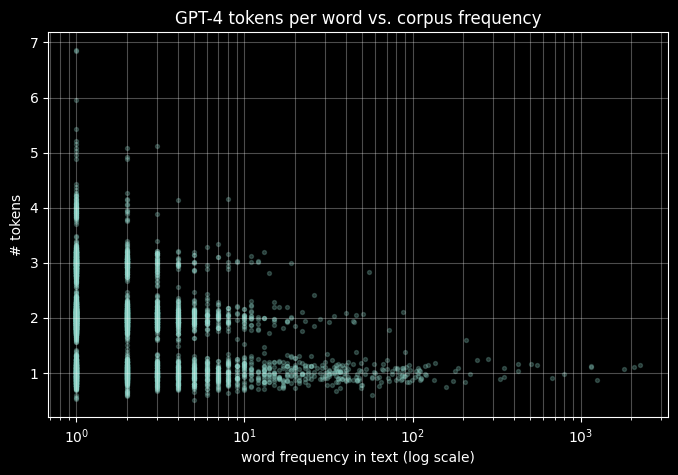

Spearman ρ = -0.353   (negative ⇒ more frequent words use fewer tokens)


In [33]:
word_freq = np.array([word_counts[w] for w in unique_words])

rng = np.random.default_rng(1)
jy = rng.normal(0, 0.15, size=token_counts.shape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(word_freq, token_counts + jy, alpha=0.25, s=8)
ax.set_xscale("log")
ax.set_xlabel("word frequency in text (log scale)")
ax.set_ylabel("# tokens")
ax.set_title("GPT-4 tokens per word vs. corpus frequency")
ax.grid(alpha=0.3, which="both")
plt.show()

rho, _ = spearmanr(word_freq, token_counts)
print(f"Spearman ρ = {rho:.3f}   (negative ⇒ more frequent words use fewer tokens)")

### Most-fragmented words

Words that explode into many tokens — usually proper nouns, archaic spellings, hyphenated compounds, or rare vocabulary that BPE never learned a long merge for.

In [34]:
order = np.argsort(token_counts)[::-1]
print("Most-tokenized words:\n")
for i in order[:10]:
    w = unique_words[i]
    pieces = [enc.decode([t]) for t in token_ids[i]]
    print(f"  {token_counts[i]:>2} tokens, {len(w):>2} chars: {w!r:<30} → {pieces}")

Most-tokenized words:

   7 tokens, 20 chars: 'plesiosaurus-haunted'         → ['p', 'les', 'ios', 'aurus', '-h', 'a', 'unted']
   7 tokens, 14 chars: 'Nebuchadnezzar'               → ['N', 'eb', 'uch', 'ad', 'ne', 'zz', 'ar']
   6 tokens, 10 chars: 'gynæceum’s'                   → ['g', 'yn', 'æ', 'ce', 'um', '’s']
   5 tokens,  9 chars: 'GUTENBERG'                    → ['G', 'UT', 'EN', 'BER', 'G']
   5 tokens, 12 chars: 'one-fiftieth'                 → ['one', '-f', 'ift', 'i', 'eth']
   5 tokens, 15 chars: 'sleight-of-hand'              → ['s', 'le', 'ight', '-of', '-hand']
   5 tokens, 16 chars: 'inextinguishable'             → ['in', 'ext', 'ingu', 'ish', 'able']
   5 tokens, 13 chars: 'unsympathetic'                → ['uns', 'y', 'mp', 'ath', 'etic']
   5 tokens, 13 chars: 'blossom-laden'                → ['b', 'loss', 'om', '-l', 'aden']
   5 tokens, 12 chars: 'rhododendron'                 → ['rh', 'od', 'od', 'end', 'ron']


### Inspect words of a given length

Pull out every unique word with exactly N characters and look at how each one is tokenized. Useful for seeing how BPE handles similar-length words very differently.

In [35]:
matches = [(w, ids) for w, ids in zip(unique_words, token_ids) if len(w) == 14]

print(f"{len(matches)} words of length 14:\n")
for w, ids in matches:
    pieces = [enc.decode([t]) for t in ids]
    print(f"  {len(ids):>2} tokens: {w!r:<18} → {pieces}")

36 words of length 14:

   7 tokens: 'Nebuchadnezzar'   → ['N', 'eb', 'uch', 'ad', 'ne', 'zz', 'ar']
   3 tokens: 'North-eastward'   → ['North', '-east', 'ward']
   3 tokens: 'Psychologist’s'   → ['Psych', 'ologist', '’s']
   3 tokens: 'Time-Dimension'   → ['Time', '-D', 'imension']
   3 tokens: 'Undergrounders'   → ['Under', 'ground', 'ers']
   3 tokens: 'aforementioned'   → ['a', 'fore', 'mentioned']
   3 tokens: 'blood-drinking'   → ['blood', '-dr', 'inking']
   2 tokens: 'characteristic'   → ['character', 'istic']
   3 tokens: 'constellations'   → ['const', 'ell', 'ations']
   3 tokens: 'conversational'   → ['con', 'vers', 'ational']
   2 tokens: 'differentiated'   → ['different', 'iated']
   2 tokens: 'disappointment'   → ['dis', 'appointment']
   3 tokens: 'discriminating'   → ['disc', 'rim', 'inating']
   3 tokens: 'disinclination'   → ['dis', 'incl', 'ination']
   3 tokens: 'expostulations'   → ['ex', 'post', 'ulations']
   2 tokens: 'ill-controlled'   → ['ill', '-controlled']


## Tokenizer efficiency

How many characters does each token "buy"? Higher = more efficient. A word tokenized as a single piece scores `len(word)`; a 4-char word that breaks into 2 tokens scores 2.0.

In [36]:
word_efficiency = word_lengths / token_counts

print(f"mean chars/token:   {word_efficiency.mean():.2f}")
print(f"median chars/token: {np.median(word_efficiency):.2f}")
print(f"range:              {word_efficiency.min():.2f} – {word_efficiency.max():.2f}")

mean chars/token:   4.14
median chars/token: 4.00
range:              1.00 – 13.00


### Distribution

Histogram of efficiency across all unique words. A peak around 1 means lots of single-char punctuation/symbols; the bulk of real words sit somewhere between 2 and 6 chars/token.

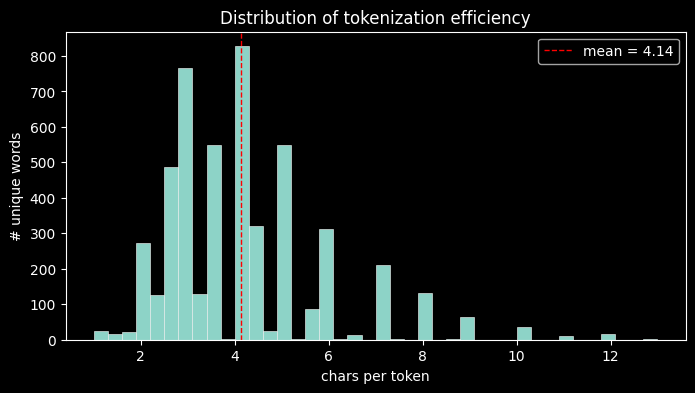

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(word_efficiency, bins=40, edgecolor="white", linewidth=0.4)
ax.axvline(word_efficiency.mean(), color="red", linestyle="--", linewidth=1,
           label=f"mean = {word_efficiency.mean():.2f}")
ax.set_xlabel("chars per token")
ax.set_ylabel("# unique words")
ax.set_title("Distribution of tokenization efficiency")
ax.legend()
plt.show()

### Extremes

Worst case: 1.00 c/t — every character needs its own token (lone punctuation, rare symbols). Best case: a long word that fits a single BPE merge.

In [38]:
order = np.argsort(word_efficiency)

print("Least efficient (most tokens per char):\n")
for i in order[:5]:
    print(f"  {word_efficiency[i]:.2f} c/t — {unique_words[i]!r} ({word_lengths[i]} chars, {token_counts[i]} tokens)")

print("\nMost efficient (fewest tokens per char):\n")
for i in order[-5:][::-1]:
    print(f"  {word_efficiency[i]:.2f} c/t — {unique_words[i]!r} ({word_lengths[i]} chars, {token_counts[i]} tokens)")

Least efficient (most tokens per char):

  1.00 c/t — '!' (1 chars, 1 tokens)
  1.00 c/t — '“' (1 chars, 1 tokens)
  1.00 c/t — '’' (1 chars, 1 tokens)
  1.00 c/t — '(' (1 chars, 1 tokens)
  1.00 c/t — ',' (1 chars, 1 tokens)

Most efficient (fewest tokens per char):

  13.00 c/t — 'communication' (13 chars, 1 tokens)
  13.00 c/t — 'advertisement' (13 chars, 1 tokens)
  12.00 c/t — 'Experimental' (12 chars, 1 tokens)
  12.00 c/t — 'modification' (12 chars, 1 tokens)
  12.00 c/t — 'conversation' (12 chars, 1 tokens)


### Efficiency by word length

For each integer word length, average chars-per-token across the words of that length, with **±1 SD** error bars showing the spread within each length bin. The curve typically rises — longer words tend to fit longer (or fewer) BPE merges, so efficiency grows with length. The bars get wider at uncommon lengths where the bin holds few words.

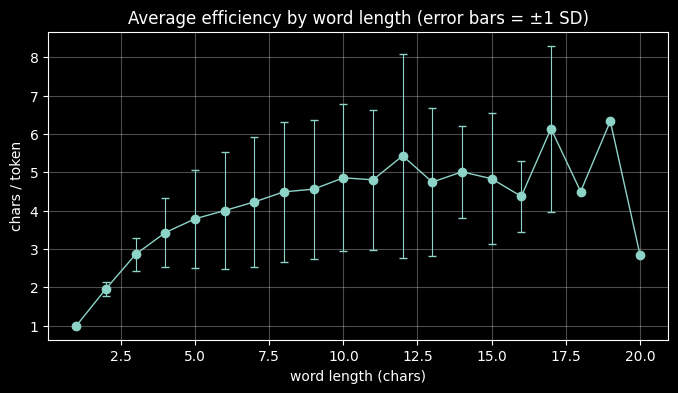

In [39]:
length_bins = np.unique(word_lengths)
mean_eff = np.array([word_efficiency[word_lengths == L].mean() for L in length_bins])
std_eff = np.array([
    word_efficiency[word_lengths == L].std(ddof=1) if (word_lengths == L).sum() > 1 else 0.0
    for L in length_bins
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(length_bins, mean_eff, yerr=std_eff,
            marker="o", capsize=3, linewidth=1, elinewidth=0.8)
ax.set_xlabel("word length (chars)")
ax.set_ylabel("chars / token")
ax.set_title("Average efficiency by word length (error bars = ±1 SD)")
ax.grid(alpha=0.3)
plt.show()

## Find a token in its natural context

Flip the viewpoint: instead of asking how a *word* breaks into tokens, pick a *token ID* and ask **where it lives in the running text**. Encode the whole book once, then for each occurrence print a window of neighbouring tokens decoded back to characters. Useful for poking at rare tokens — you can see whether a token only ever shows up next to one specific phrase (e.g. `" Por"` always preceding `"celain"`), or whether it pulls its weight across many contexts.

In [40]:
token_text = enc.encode(text)
print(f"{len(token_text):,} tokens in the full text ({len(text) / len(token_text):.2f} chars/token)")

43,053 tokens in the full text (4.25 chars/token)


In [41]:
chosen_token = 20388     # ' Por' — try 11 (','), 13 ('.'), 279 (' the'), or any id from token_text
context = 5              # # of tokens of context on each side
max_matches = 25         # cap printed occurrences

# enumerate gives the *position* in the sequence; tid is the token VALUE.
# Indexing token_text by position pulls the real neighbours from the text —
# `chosen_token ± k` would just be the neighbours in the vocabulary.
positions = [pos for pos, tid in enumerate(token_text) if tid == chosen_token]
print(f"token {chosen_token} = {enc.decode([chosen_token])!r} — {len(positions)} occurrence(s)\n")

for pos in positions[:max_matches]:
    before = enc.decode(token_text[max(0, pos - context) : pos])
    here   = enc.decode([chosen_token])
    after  = enc.decode(token_text[pos + 1 : pos + 1 + context])
    # Decode the *slice* (not token-by-token) so multi-byte chars that span
    # tokens come back as proper Unicode rather than mojibake.
    print(f"  {before!r:>45} ⟨{here}⟩ {after!r}")

token 20388 = ' Por' — 9 occurrence(s)

                      ' XI The Palace of Green' ⟨ Por⟩ 'celain\r\n XII In the'
               ' regarding the Palace of Green' ⟨ Por⟩ 'celain was a piece of'
                      ' of the Palace of Green' ⟨ Por⟩ 'celain and the polished gle'
                          '\r\nPalace of Green' ⟨ Por⟩ 'celain to her, and'
                    '.\r\n The Palace of Green' ⟨ Por⟩ 'celain\r\n\r\n\r\n“I found the'
                   ' found the Palace of Green' ⟨ Por⟩ 'celain, when we approached'
                       ', this Palace of Green' ⟨ Por⟩ 'celain\r\nhad a great'
                      ' the Palace of\r\nGreen' ⟨ Por⟩ 'celain. I found myself'
                      'oke the Palace of Green' ⟨ Por⟩ 'celain, and from that'
